# Импорт библиотек

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN

# Выгрузка данных

In [4]:
df = pd.read_csv('/content/27_B_17834.csv', sep=';', decimal=',')
df

,X,Y
0,7.084,7.959
1,-0.759,5.781
2,6.736,4.640
3,7.899,7.361
4,0.297,5.932
...,...,...
9895,5.910,-1.384
9896,2.601,0.671
9897,-0.361,5.778
9898,7.805,6.691


# Кластеризация

In [13]:
dbscan = DBSCAN(eps=1)
df['clusters'] = dbscan.fit_predict(df[['X', 'Y']])

print("Всего кластеров и сколько звезд в этих кластерах:")
print(df['clusters'].value_counts())

Всего кластеров и сколько звезд в этих кластерах:
clusters
1    3500
0    3200
2    3200
Name: count, dtype: int64


# Поиск центроидов

In [36]:
centers = []
all_clusters = sorted(df['clusters'].unique())

for i in all_clusters:
  df_i = df[df['clusters'] == i]
  min_distance = float('inf')
  center_i = None
  points = df_i[['X', 'Y']].values
  for index, might_be_a_center in df_i.iterrows():
    candidate_point = might_be_a_center[['X', 'Y']].values
    distance = np.linalg.norm(points - candidate_point, axis=1)
    total_distance = distance.sum()
    if total_distance < min_distance:
      min_distance = total_distance
      center_i = might_be_a_center
  centers.append(center_i)
for i in centers:
  print(f"Центроид {i['clusters']} кластера: ({i['X']}, {i['Y']})")

Центроид 0.0 кластера: (7.563, 5.851)
Центроид 1.0 кластера: (0.549, 5.016)
Центроид 2.0 кластера: (4.146, -0.294)


# График

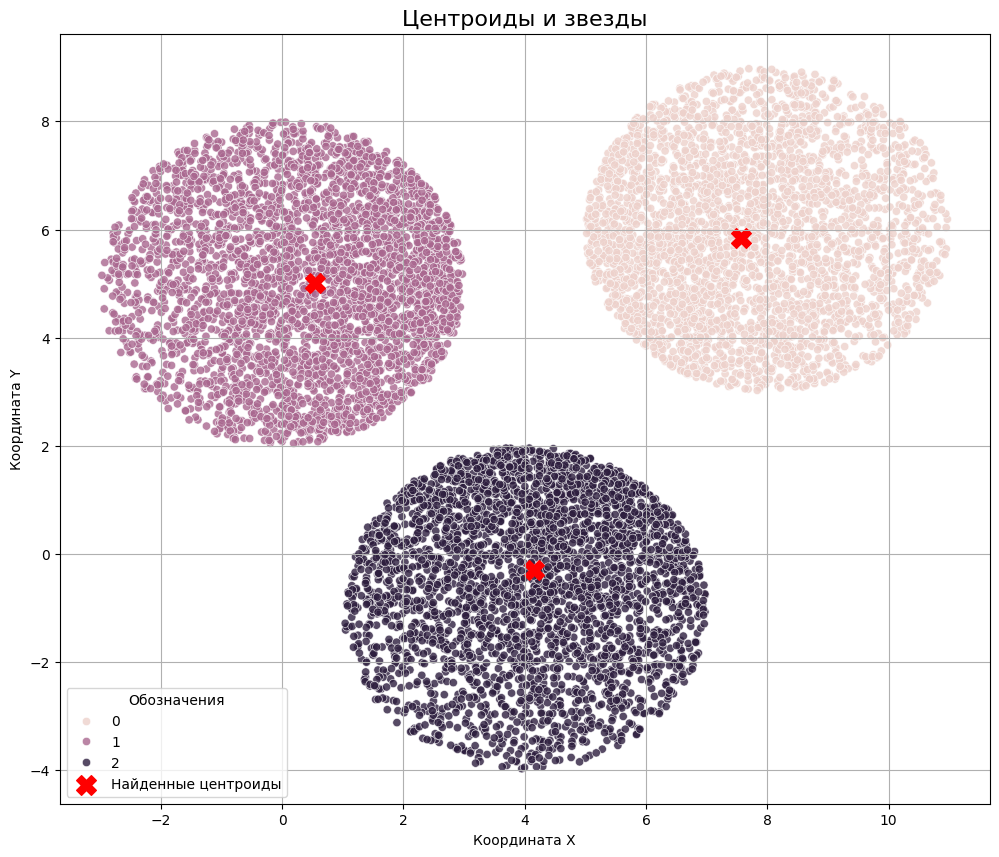

In [44]:
centers_df = pd.DataFrame(centers, columns=['X', 'Y'])

plt.figure(figsize=(12, 10))
sns.scatterplot(data=df, x='X', y='Y', hue='clusters', alpha=0.8)
plt.scatter(x=centers_df['X'], y=centers_df['Y'], marker='X', s=200, c='red', label='Найденные центроиды')

plt.title('Центроиды и звезды', fontsize=16)
plt.xlabel('Координата X')
plt.ylabel('Координата Y')
plt.legend(title='Обозначения')
plt.grid(True)
plt.show()
